> (중요) 여러분 구글 드라이브에 최소 7GB 이상은 확보되어 있어야 합니다!

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import unicodedata  # 0번 섹션에 추가 필요

# 📌 경로 설정 (제공해주신 경로 반영)
def normalize_path(path):
    # 1. unicodedata.normalize('NFC', path): 경로 문자열을 NFC 방식으로 통일
    # 2. .strip(): 앞뒤에 붙은 불필요한 공백 제거
    return unicodedata.normalize('NFC', path).strip()

> (주의) 아래 코드는 처음 딱 한 번만!

In [3]:
# import zipfile
# import os
# import shutil
# import time

# # 1. 경로 설정
# dataset_zip = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/초급_프로젝트_수강생_배포용.zip")
# extract_path = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/")

# os.makedirs(extract_path, exist_ok=True)

# # 2. 메인 압축파일 해제
# print(f"📦 메인 데이터셋 해제 중: {os.path.basename(dataset_zip)}")
# with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# # 메인 압축파일 삭제 (요청사항)
# os.remove(dataset_zip)
# print("🗑️ 메인 압축파일 삭제 완료.")

# # 3. 내부 이미지 압축파일 통합 해제 로직
# print("\n🚀 이미지 폴더 통합 및 내부 압축 해제 시작...")
# for file in os.listdir(extract_path):
#     if file.endswith(".zip"):
#         file_path = os.path.join(extract_path, file)
        
#         # 이름 기반 대상 폴더 결정 (train/test 통합)
#         if 'train' in file.lower():
#             target_folder_name = "train_images"
#         elif 'test' in file.lower():
#             target_folder_name = "test_images"
#         else:
#             target_folder_name = file.replace(".zip", "")

#         target_subfolder = os.path.join(extract_path, target_folder_name)
#         os.makedirs(target_subfolder, exist_ok=True)

#         print(f"📂 {file} -> {target_folder_name} 통합 중...")
        
#         with zipfile.ZipFile(file_path, 'r') as zip_ref:
#             for member in zip_ref.infolist():
#                 if not member.is_dir():
#                     # 내부 경로 구조를 무시하고 파일명만 추출하여 저장
#                     filename = os.path.basename(member.filename)
#                     if filename:
#                         target_file_path = os.path.join(target_subfolder, filename)
#                         with zip_ref.open(member) as source, open(target_file_path, "wb") as target:
#                             shutil.copyfileobj(source, target)
        
#         # [수정 포인트] 삭제 전 잠시 대기 후 강제 삭제 시도
#         try:
#             time.sleep(0.5) 
#             if os.path.exists(file_path):
#                 os.remove(file_path)
#                 print(f"🗑️ 삭제 성공: {file}")
#         except Exception as e:
#             print(f"❌ {file} 삭제 실패: {e}")

# print("\n✨ 모든 작업이 완료되었습니다!")
# print(f"📁 최종 데이터셋 구성: {os.listdir(extract_path)}")

- 구글 드라이브 휴지통 비우기

In [4]:
# from google.colab import auth
# from googleapiclient.discovery import build

# # 1. 구글 드라이브 인증
# auth.authenticate_user()
# drive_service = build('drive', 'v3')

# # 2. 휴지통 완전히 비우기 함수
# def empty_trash():
#     try:
#         drive_service.files().emptyTrash().execute()
#         print("✅ 구글 드라이브 휴지통이 완전히 비워졌습니다.")
#     except Exception as e:
#         print(f"❌ 휴지통 비우기 실패: {e}")

# # 실행
# empty_trash()

> 압축 해제한 파일들의 반영 시간이 걸릴 수 있으므로, 커널 재시작 해주기!

#### `normalize_path`는?

`normalize_path`는 파일 경로에 포함된 **한글(유니코드) 처리 방식**을 통일하여, 경로를 찾지 못하는 에러를 방지하기 위한 함수입니다.

특히 **Google Colab**이나 **Mac, Windows** 사이에서 데이터를 주고받을 때 한글 폴더명이 깨져서 발생하는 `File Not Found` 에러를 잡는 데 필수적입니다.

<br>

##### 왜 사용하나요? (NFC vs NFD)

한글을 컴퓨터가 인식하는 방식은 크게 두 가지입니다.

* **NFC (Windows 스타일):** '강'을 '강'이라는 하나의 글자로 저장합니다.
* **NFD (Mac/Unix 스타일):** '강'을 'ㄱ', 'ㅏ', 'ㅇ'으로 쪼개서 저장합니다.

사람 눈에는 똑같이 "초급 프로젝트"라고 보이지만, 컴퓨터 입장에서는 글자 조합 방식이 다르면 **완전히 다른 경로**로 인식합니다. `normalize_path` 는 이를 **NFC(표준 방식)** 로 강제 통일해주는 역할을 합니다.

In [9]:
############################################################
# 0. 라이브러리 임포트 & 경로 설정
############################################################
import os
import json
import pandas as pd
from PIL import Image
import unicodedata  # 0번 섹션에 추가 필요
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 📌 경로 설정 (제공해주신 경로 반영)
def normalize_path(path):
    # 1. unicodedata.normalize('NFC', path): 경로 문자열을 NFC 방식으로 통일
    # 2. .strip(): 앞뒤에 붙은 불필요한 공백 제거
    return unicodedata.normalize('NFC', path).strip()

**yolo용 폴더 구조로 변환**

> 기존 이미지와 라벨들을 아래 구조처럼 맞춰줌.

```bash
/content/dataset/
  ├── train/
  │    ├── images/  #<-- 여기에 .jpg 파일들 이동
  │    └── labels/  #<-- 여기에 .txt 파일들 생성
  └── val/
       ├── images/  #<-- 여기에 .jpg 파일들 이동
       └── labels/  #<-- 여기에 .txt 파일들 생성
```

> 한 번만 실행하기

In [ ]:
import os
import shutil

base_path = extract_path # 실제 dataset 폴더 경로로 수정하세요

def reorganize_yolo(mode):
    # 기존 폴더명 (예: train_images, test_images)
    old_img_dir = os.path.join(base_path, f'{mode}_images')
    
    # 새로운 표준 구조 (예: train/images, train/labels)
    new_root = os.path.join(base_path, mode if mode == 'train' else 'val')
    new_img_dir = os.path.join(new_root, 'images')
    new_lbl_dir = os.path.join(new_root, 'labels')
    
    os.makedirs(new_img_dir, exist_ok=True)
    os.makedirs(new_lbl_dir, exist_ok=True)
    
    # 이미지 파일 이동
    for f in os.listdir(old_img_dir):
        shutil.move(os.path.join(old_img_dir, f), os.path.join(new_img_dir, f))

# 실행
reorganize_yolo('train')
reorganize_yolo('test') # test를 val 용도로 변경

In [21]:
# 경로는 환경에 맞게 수정
# train_images, test_images
extract_path = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/") # 압축을 풀 폴더

TRAIN_JSON_PATH = os.path.join(extract_path, "merged_annotations_train_final.json")
TEST_JSON_PATH = os.path.join(extract_path, "merged_annotations_test_final.json")
TRAIN_IMG_DIR = os.path.join(extract_path, "train", "images")
TEST_IMG_DIR  = os.path.join(extract_path, "val", "images")

# merged_annotation json 경로
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
TEST_IMG_DIR

'/content/drive/MyDrive/data/초급_프로젝트/dataset/val/images'

In [20]:
############################################################
# 1. 병합된 JSON 파일을 읽어서 DataFrame으로 만들기
############################################################

def build_df_from_merged_json(json_path, img_dir, train_flag):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    id_to_fname = {img["id"]: img["file_name"] for img in data["images"]}

    records = []
    # 2) 어노테이션 순회
    for ann in data["annotations"]:
        img_id_coco = ann["image_id"]
        
        if train_flag: # 학습데이터면,
        # 1) 이미지 정보 매핑 (id -> file_name)
            file_name = id_to_fname.get(img_id_coco)
            
            if file_name is None: continue
            
            img_path = os.path.join(img_dir, file_name)
        else:
            file_name = str(img_id_coco) + ".png"
            img_path = os.path.join(img_dir, file_name)
        
        # 실제 이미지 파일이 있는지 확인 (선택 사항이지만 안전함)
        if not os.path.exists(img_path):
            continue

        x, y, w, h = ann["bbox"]
        
        records.append({
            "image_path": img_path,
            "image_id": os.path.splitext(file_name)[0], # 파일명을 ID로 사용
            "category_id": int(ann["category_id"]),
            "bbox_x": float(x),
            "bbox_y": float(y),
            "bbox_w": float(w),
            "bbox_h": float(h),
        })

    return pd.DataFrame(records)

In [23]:
TRAIN_IMG_DIR

'/content/drive/MyDrive/data/초급_프로젝트/dataset/train/images'

In [24]:
train_df = build_df_from_merged_json(TRAIN_JSON_PATH, TRAIN_IMG_DIR, train_flag=True)
val_df = build_df_from_merged_json(TEST_JSON_PATH, TEST_IMG_DIR, train_flag=False)

In [25]:
# 1. 고유 category_id 추출 및 정렬
unique_cats = sorted(train_df["category_id"].unique())
num_classes = len(unique_cats)

# 2. YOLO용 매핑 (0부터 시작)
# 예: 원본 [10, 25, 30] -> YOLO [0, 1, 2]
orig2yolo = {cid: i for i, cid in enumerate(unique_cats)}
yolo2orig = {i: cid for cid, i in orig2yolo.items()}

print(f"✅ YOLO용 클래스 개수: {num_classes}")
print(f"✅ 매핑 결과 (원본:YOLO): {orig2yolo}")

# 3. (중요) 이 매핑 정보를 data.yaml의 'names'에 넣어야 합니다.
# 만약 알약 이름 데이터가 있다면 리스트로 만드세요.
class_names = [str(yolo2orig[i]) for i in range(num_classes)]

✅ YOLO용 클래스 개수: 73
✅ 매핑 결과 (원본:YOLO): {np.int64(1899): 0, np.int64(2482): 1, np.int64(3350): 2, np.int64(3482): 3, np.int64(3543): 4, np.int64(3742): 5, np.int64(3831): 6, np.int64(4377): 7, np.int64(4542): 8, np.int64(5093): 9, np.int64(5885): 10, np.int64(6191): 11, np.int64(6562): 12, np.int64(10220): 13, np.int64(12080): 14, np.int64(12246): 15, np.int64(12419): 16, np.int64(12777): 17, np.int64(13394): 18, np.int64(13899): 19, np.int64(16231): 20, np.int64(16261): 21, np.int64(16547): 22, np.int64(16550): 23, np.int64(16687): 24, np.int64(18109): 25, np.int64(18146): 26, np.int64(18356): 27, np.int64(19231): 28, np.int64(19551): 29, np.int64(19606): 30, np.int64(19860): 31, np.int64(20013): 32, np.int64(20237): 33, np.int64(20876): 34, np.int64(21025): 35, np.int64(21324): 36, np.int64(21770): 37, np.int64(22073): 38, np.int64(22346): 39, np.int64(22361): 40, np.int64(22626): 41, np.int64(23202): 42, np.int64(23222): 43, np.int64(24849): 44, np.int64(25366): 45, np.int64(25437): 4

> YOLO val을 test_images 폴더로 사용

In [26]:
orig2yolo

{np.int64(1899): 0,
 np.int64(2482): 1,
 np.int64(3350): 2,
 np.int64(3482): 3,
 np.int64(3543): 4,
 np.int64(3742): 5,
 np.int64(3831): 6,
 np.int64(4377): 7,
 np.int64(4542): 8,
 np.int64(5093): 9,
 np.int64(5885): 10,
 np.int64(6191): 11,
 np.int64(6562): 12,
 np.int64(10220): 13,
 np.int64(12080): 14,
 np.int64(12246): 15,
 np.int64(12419): 16,
 np.int64(12777): 17,
 np.int64(13394): 18,
 np.int64(13899): 19,
 np.int64(16231): 20,
 np.int64(16261): 21,
 np.int64(16547): 22,
 np.int64(16550): 23,
 np.int64(16687): 24,
 np.int64(18109): 25,
 np.int64(18146): 26,
 np.int64(18356): 27,
 np.int64(19231): 28,
 np.int64(19551): 29,
 np.int64(19606): 30,
 np.int64(19860): 31,
 np.int64(20013): 32,
 np.int64(20237): 33,
 np.int64(20876): 34,
 np.int64(21025): 35,
 np.int64(21324): 36,
 np.int64(21770): 37,
 np.int64(22073): 38,
 np.int64(22346): 39,
 np.int64(22361): 40,
 np.int64(22626): 41,
 np.int64(23202): 42,
 np.int64(23222): 43,
 np.int64(24849): 44,
 np.int64(25366): 45,
 np.int64(2

In [27]:
import os
import yaml
from tqdm import tqdm
from PIL import Image

# 1. YOLO 전용 라벨 저장 경로 설정 (원본 폴더 내부에 생성)
# YOLO는 이미지 폴더와 같은 위치에 'labels'라는 이름의 폴더가 있는 것을 선호합니다.
YOLO_TRAIN_LABELS = os.path.join(extract_path, "train", "labels")
YOLO_TEST_LABELS = os.path.join(extract_path, "val", "labels")

os.makedirs(YOLO_TRAIN_LABELS, exist_ok=True)
os.makedirs(YOLO_TEST_LABELS, exist_ok=True)

def convert_to_yolo_labels(df, save_dir):
    print(f"📂 라벨 변환 중: {save_dir}")
    for img_path, group in tqdm(df.groupby("image_path")):
        # 1. 이미지 크기 확인 (정규화 필수)
        with Image.open(img_path) as img:
            w_img, h_img = img.size
        
        file_name = os.path.basename(img_path)
        label_name = os.path.splitext(file_name)[0] + ".txt"
        label_path = os.path.join(save_dir, label_name)
        
        with open(label_path, "w") as f:
            for _, row in group.iterrows():
                # COCO(x,y,w,h) -> YOLO(cx, cy, w, h) 정규화
                cx = (row['bbox_x'] + row['bbox_w'] / 2) / w_img
                cy = (row['bbox_y'] + row['bbox_h'] / 2) / h_img
                nw = row['bbox_w'] / w_img
                nh = row['bbox_h'] / h_img
                
                # 클래스 ID 기록 (보통 0부터 시작)
                f.write(f"{orig2yolo[int(row['category_id'])]} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n")

# 2. 학습/테스트 데이터 라벨 생성
# (기존에 정의하신 build_df_from_merged_json 함수로 만든 df를 사용하세요)

convert_to_yolo_labels(train_df, YOLO_TRAIN_LABELS)
convert_to_yolo_labels(val_df, YOLO_TEST_LABELS)

📂 라벨 변환 중: /content/drive/MyDrive/data/초급_프로젝트/dataset/train/labels


100%|██████████| 1489/1489 [00:09<00:00, 152.62it/s]


📂 라벨 변환 중: /content/drive/MyDrive/data/초급_프로젝트/dataset/val/labels


100%|██████████| 843/843 [00:05<00:00, 154.07it/s]


**라이브러리 설치**

In [28]:
!pip install ultralytics

**data.yaml 파일 생성**

In [29]:
import yaml

data_config = {
    'path': extract_path,           # 부모 경로
    'train': 'train/images',        # 학습용 이미지 폴더명
    'val': 'val/images',           # 검증용 이미지 폴더명 (질문하신 부분!)
    'nc': num_classes,            # 클래스 개수
    'names': [f"pill_{i}" for i in range(num_classes)] # 클래스 이름
}

yaml_path = os.path.join(extract_path, "pill_data.yaml")
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(data_config, f)

In [30]:
data_config

{'path': '/content/drive/MyDrive/data/초급_프로젝트/dataset/',
 'train': 'train/images',
 'val': 'val/images',
 'nc': 73,
 'names': ['pill_0',
  'pill_1',
  'pill_2',
  'pill_3',
  'pill_4',
  'pill_5',
  'pill_6',
  'pill_7',
  'pill_8',
  'pill_9',
  'pill_10',
  'pill_11',
  'pill_12',
  'pill_13',
  'pill_14',
  'pill_15',
  'pill_16',
  'pill_17',
  'pill_18',
  'pill_19',
  'pill_20',
  'pill_21',
  'pill_22',
  'pill_23',
  'pill_24',
  'pill_25',
  'pill_26',
  'pill_27',
  'pill_28',
  'pill_29',
  'pill_30',
  'pill_31',
  'pill_32',
  'pill_33',
  'pill_34',
  'pill_35',
  'pill_36',
  'pill_37',
  'pill_38',
  'pill_39',
  'pill_40',
  'pill_41',
  'pill_42',
  'pill_43',
  'pill_44',
  'pill_45',
  'pill_46',
  'pill_47',
  'pill_48',
  'pill_49',
  'pill_50',
  'pill_51',
  'pill_52',
  'pill_53',
  'pill_54',
  'pill_55',
  'pill_56',
  'pill_57',
  'pill_58',
  'pill_59',
  'pill_60',
  'pill_61',
  'pill_62',
  'pill_63',
  'pill_64',
  'pill_65',
  'pill_66',
  'pill_67',
 

**YOLOv11 학습**

In [31]:
from ultralytics import YOLO

# 1. 모델 로드
model = YOLO('yolo11m.pt') 

# 2. 학습 실행
model.train(
    data=yaml_path,
    epochs=5, # 0점 안나오는 지 확인을 위해서, 5번만 돌립니다!
    patience=5,      # 5번 동안 성능 향상이 없으면 알아서 멈춥니다!
    imgsz=640,
    device=0,  # GPU 사용
    name='pill_detection_project'
)

Ultralytics 8.4.27 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/data/초급_프로젝트/dataset/pill_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pill_detection_project8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7876c00d82c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0

In [ ]:
# 1. 현재 파이썬이 어디서 일하고 있는지 확인
print(f"📍 현재 작업 디렉토리: {os.getcwd()}")

# 2. 내 컴퓨터 전체(혹은 현재 폴더 하위)에서 best.pt를 샅샅이 뒤지기
for root, dirs, files in os.walk(os.getcwd()):
    if "best.pt" in files:
        print(f"🎯 찾았다! 실제 경로: {os.path.join(root, 'best.pt')}")

**추론 및 CSV 생성**

In [ ]:
!ls /content/runs/detect/pill_detection_project8/weights/

best.pt  last.pt


In [44]:
from ultralytics import YOLO
import pandas as pd
import os

# 1. 모델 불러오기
best_model_path = "/content/runs/detect/pill_detection_project8/weights/best.pt"
model = YOLO(best_model_path)
print("✅ best.pt 로드 완료!")

# 2. 테스트 이미지 추론 시작
print("🚀 테스트 이미지 843장 추론 시작...")
results = model.predict(source=TEST_IMG_DIR, imgsz=640, conf=0.25)

rows = []
for r in results:
    # image_id를 정수로 (숫자 정렬 이슈 방지)
    image_id = int(os.path.splitext(os.path.basename(r.path))[0])
    
    for box in r.boxes:
        cls_id = int(box.cls[0])
        # 매핑 규칙: 0~72 -> 1~73 -> 원본 ID
        orig_cat = yolo2orig[cls_id]
        
        # ⭐ '+1' 적용
        final_category_id = int(orig_cat) + 1
        
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        
        rows.append({
            "image_id": image_id,
            "category_id": final_category_id,
            "bbox_x": x1,
            "bbox_y": y1,
            "bbox_w": x2 - x1,
            "bbox_h": y2 - y1,
            "score": float(box.conf[0])
        })

# 3. 데이터프레임 생성 및 상위 4개 필터링
df_sub = pd.DataFrame(rows)
df_sub = df_sub.sort_values(by=["image_id", "score"], ascending=[True, False])
df_sub = df_sub.groupby("image_id").head(4)

# 4. annotation_id 부여
df_sub.insert(0, "annotation_id", range(1, len(df_sub) + 1))

# 5. CSV 저장
output_path = os.path.join(extract_path, "submission_YOLOv11_SUCCESS.csv")
df_sub.to_csv(output_path, index=False)

print(f"✅ 제출 파일 생성 완료: {output_path}")

✅ best.pt 로드 완료!
🚀 테스트 이미지 843장 추론 시작...

image 1/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/val/images/1.png: 640x512 1 pill_0, 1 pill_23, 1 pill_44, 1 pill_51, 13.1ms
image 2/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/val/images/10.png: 640x512 1 pill_0, 1 pill_22, 1 pill_37, 1 pill_55, 12.0ms
image 3/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/val/images/100.png: 640x512 1 pill_0, 1 pill_22, 1 pill_25, 1 pill_63, 12.4ms
image 4/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/val/images/1003.png: 640x512 1 pill_3, 1 pill_20, 1 pill_49, 1 pill_67, 12.5ms
image 5/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/val/images/1004.png: 640x512 1 pill_3, 1 pill_20, 1 pill_49, 1 pill_67, 12.1ms
image 6/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/val/images/1005.png: 640x512 1 pill_3, 1 pill_20, 1 pill_49, 1 pill_67, 12.4ms
image 7/843 /content/drive/MyDrive/data/초급_프로젝트/dataset/val/images/1006.png: 640x512 1 pill_3, 1 pill_33, 1 pill_45, 1 pill_47, 12.0ms
image 8/843 /conten

In [45]:
df_sub

,annotation_id,image_id,category_id,bbox_x,bbox_y,bbox_w,bbox_h,score
0,1,1,27926,599.161255,671.991943,255.955566,481.466064,0.900314
1,2,1,16551,560.818359,70.802063,387.707520,403.922302,0.827779
2,3,1,1900,158.217896,251.072327,203.336121,123.674866,0.674871
3,4,1,24850,174.314590,741.693604,178.283066,290.643066,0.250152
1548,5,3,16551,526.452271,61.523392,384.007080,397.541122,0.847324
...,...,...,...,...,...,...,...,...
1193,3191,1497,19861,84.046265,824.604431,228.023041,177.941528,0.757216
1194,3192,1497,34597,52.841309,62.953674,314.687317,492.421082,0.719523
1201,3193,1500,38162,197.292053,732.336792,184.263855,297.608276,0.897502
1202,3194,1500,3351,351.088867,236.098358,184.491577,183.509460,0.873032


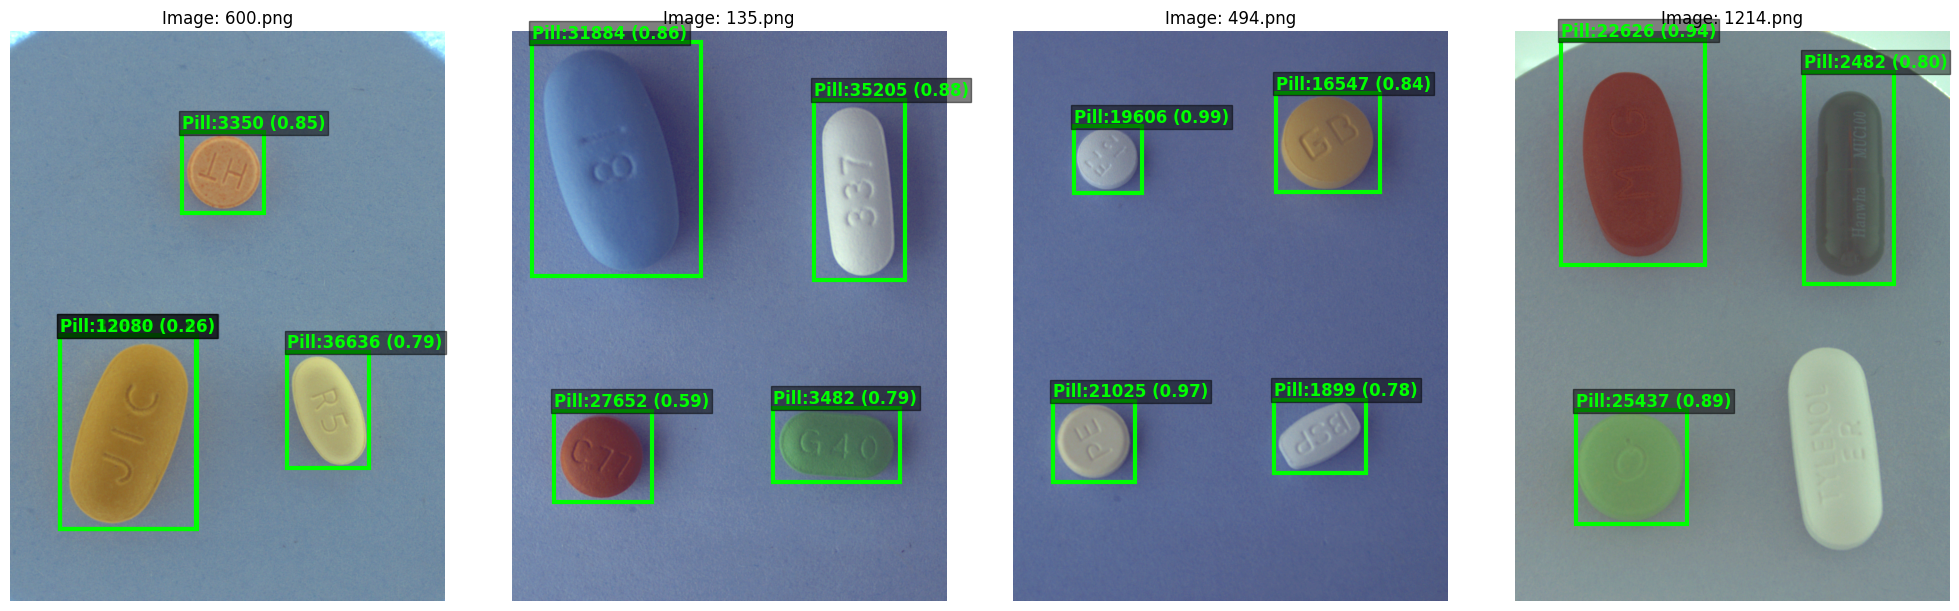

✅ 랜덤하게 선택된 4장의 이미지 시각화 완료!


In [43]:
import matplotlib.pyplot as plt
import cv2
import random

# --- 기존 코드의 2번 단계 바로 뒤에 추가 ---

# [시각화 설정]
NUM_SAMPLES = 4      # 보여줄 랜덤 이미지 개수
CONF_THRES = 0.25    # 박스를 그릴 최소 신뢰도 (predict와 맞춤)

# 1. 랜덤하게 시각화할 이미지 선택
# results 객체는 리스트이므로 인덱스로 접근합니다.
sample_indices = random.sample(range(len(results)), NUM_SAMPLES)

# 2. 시각화 루프 시작
plt.figure(figsize=(20, 10)) # 전체 그림 크기 설정

for i, idx in enumerate(sample_indices):
    r = results[idx]
    
    # 원본 이미지 로드 (BGR -> RGB 변환 필수)
    img = cv2.imread(r.path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 이미지 파일명 추출
    file_name = os.path.basename(r.path)
    
    # 서브플롯 생성
    plt.subplot(1, NUM_SAMPLES, i + 1)
    plt.imshow(img)
    plt.title(f"Image: {file_name}")
    plt.axis('off') # 축 숨기기
    
    # 3. 해당 이미지의 검출된 박스들 그리기
    for box in r.boxes:
        conf = float(box.conf[0])
        
        # 신뢰도 임계값 체크
        if conf < CONF_THRES:
            continue
            
        # 좌표 (xyxy 포맷)
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls_id = int(box.cls[0])
        
        # 원본 카테고리 ID로 변환 (yolo2orig 매핑 사용)
        orig_cat = yolo2orig[cls_id]
        
        # 박스 그리기
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, 
                             fill=False, edgecolor='lime', linewidth=3)
        plt.gca().add_patch(rect)
        
        # 라벨 텍스트 추가 (클래스 ID + 신뢰도)
        label_text = f"Pill:{orig_cat} ({conf:.2f})"
        plt.text(x1, y1 - 10, label_text, color='lime', 
                 fontsize=12, fontweight='bold',
                 bbox=dict(facecolor='black', alpha=0.5, pad=2))

plt.tight_layout()
plt.show()

print(f"✅ 랜덤하게 선택된 {NUM_SAMPLES}장의 이미지 시각화 완료!")

# --- 이후 기존 코드의 3번(데이터프레임 생성) 단계로 이어짐 ---